# GATE DA Question Graph Analysis

This notebook builds a graph from **all questions currently present in this project**.

It uses:
- the main practice question bank from `src/data/questions.ts`
- every full test exported through `src/data/fullTests.ts`
- structural links such as subject, topic, difficulty, and test membership
- question-to-question links based on topic overlap, metadata fit, and text similarity

Use it when you want to:
- inspect the full question inventory
- see how questions cluster by subject/topic/difficulty
- visualize graph neighborhoods
- export the graph to GraphML or JSON for downstream tooling


In [27]:
import json
import math
import re
import subprocess
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from IPython.display import display
from matplotlib.gridspec import GridSpec

# NumPy 2.x compatibility for older NetworkX drawing internals.
if not hasattr(np, "alltrue"):
    np.alltrue = np.all

try:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity
    SKLEARN_AVAILABLE = True
except Exception:
    SKLEARN_AVAILABLE = False

ROOT = Path.cwd()
EXPORTER = ROOT / "tools" / "export_question_bank.mjs"
EXPORT_JSON = ROOT / "tmp_question_bank_export.json"

DIFF_ORDER = {"easy": 0, "medium": 1, "hard": 2}
DIFF_COLOR = {"easy": "#2ecc71", "medium": "#f39c12", "hard": "#e74c3c"}
SUBJECT_COLORS = {
    "general-aptitude": "#ff6b6b",
    "linear-algebra": "#4dabf7",
    "probability-statistics": "#51cf66",
    "calculus-optimization": "#ffd43b",
    "machine-learning": "#845ef7",
    "ai": "#f06595",
    "programming-dsa": "#ffa94d",
    "database-warehousing": "#20c997",
}


In [28]:
# ============================================================
# 1. EXPORT THE REAL QUESTION BANK FROM THIS PROJECT
# ============================================================

if not EXPORTER.exists():
    raise FileNotFoundError(f"Missing exporter: {EXPORTER}")

subprocess.run(
    ["node", str(EXPORTER), str(EXPORT_JSON)],
    cwd=ROOT,
    check=True,
)

payload = json.loads(EXPORT_JSON.read_text(encoding="utf-8"))

print("Generated at:", payload.get("generatedAt"))
print("Practice-bank questions:", len(payload.get("questions", [])))
print("Full tests:", len(payload.get("tests", [])))


Generated at: 2026-04-24T06:19:17.219Z
Practice-bank questions: 828
Full tests: 10


In [29]:
# ============================================================
# 2. FLATTEN EVERY QUESTION INSTANCE ACROSS THE PROJECT
# ============================================================

def normalize_text(value: str) -> str:
    return " ".join(str(value or "").strip().lower().split())


def normalize_list(value):
    if isinstance(value, list):
        return [str(item).strip() for item in value]
    if value is None:
        return []
    return [str(value).strip()]


def canonical_key(row: dict) -> str:
    return " | ".join(
        [
            normalize_text(row.get("subjectId", "")),
            normalize_text(row.get("topicId", "")),
            normalize_text(row.get("type", "mcq")),
            normalize_text(row.get("question", "")),
        ]
    )


rows = []

for question in payload.get("questions", []):
    row = dict(question)
    row["source_type"] = "practice-bank"
    row["source_test_id"] = None
    row["source_test_title"] = None
    row["canonical_key"] = canonical_key(row)
    rows.append(row)

for test in payload.get("tests", []):
    for index, question in enumerate(test.get("questions", []), start=1):
        row = dict(question)
        row["source_type"] = "full-test"
        row["source_test_id"] = test.get("id")
        row["source_test_title"] = test.get("title")
        row["source_question_number"] = index
        row["canonical_key"] = canonical_key(row)
        rows.append(row)

instances_df = pd.DataFrame(rows)
instances_df["difficulty"] = instances_df["difficulty"].fillna("medium").str.lower()
instances_df["eloRating"] = pd.to_numeric(instances_df["eloRating"], errors="coerce").fillna(1400)
instances_df["marks"] = pd.to_numeric(instances_df["marks"], errors="coerce").fillna(1)
instances_df["negativeMarks"] = pd.to_numeric(instances_df["negativeMarks"], errors="coerce").fillna(0)
instances_df["instance_count"] = instances_df.groupby("canonical_key")["canonical_key"].transform("count")

print("All question instances across the project:", len(instances_df))
display(
    instances_df[
        [
            "id",
            "subjectId",
            "topicId",
            "difficulty",
            "eloRating",
            "source_type",
            "source_test_id",
            "instance_count",
        ]
    ].head(12)
)


All question instances across the project: 1478


,id,subjectId,topicId,difficulty,eloRating,source_type,source_test_id,instance_count
0,mock2-q1,general-aptitude,ga-verbal-reasoning,easy,1200.0,practice-bank,None,3
1,mock2-q2,general-aptitude,ga-verbal-reasoning,easy,1200.0,practice-bank,None,3
2,mock2-q3,probability-statistics,ps-probability,easy,1200.0,practice-bank,None,3
3,mock2-q4,general-aptitude,ga-quantitative-aptitude,easy,1200.0,practice-bank,None,3
4,mock2-q5,general-aptitude,ga-quantitative-aptitude,easy,1200.0,practice-bank,None,3
5,mock2-q6,calculus-optimization,co-differentiation,medium,1450.0,practice-bank,None,3
6,mock2-q7,probability-statistics,ps-probability,medium,1450.0,practice-bank,None,3
7,mock2-q8,calculus-optimization,co-integration,medium,1450.0,practice-bank,None,3
8,mock2-q9,general-aptitude,ga-logical-reasoning,medium,1450.0,practice-bank,None,3
9,mock2-q10,general-aptitude,ga-logical-reasoning,easy,1300.0,practice-bank,None,2


In [30]:
# ============================================================
# 3. DEDUPLICATE INTO UNIQUE QUESTION NODES
# ============================================================

questions_df = (
    instances_df
    .sort_values(["source_type", "id"], na_position="last")
    .drop_duplicates("canonical_key")
    .reset_index(drop=True)
)

questions_df["node_id"] = [f"q_{i}" for i in range(len(questions_df))]
questions_df["difficulty_num"] = questions_df["difficulty"].map(DIFF_ORDER).fillna(1).astype(int)
questions_df["text_blob"] = questions_df.apply(
    lambda row: " ".join(
        [
            str(row.get("question", "")),
            str(row.get("explanation", "")),
            " ".join(normalize_list(row.get("options", []))),
            str(row.get("subjectId", "")),
            str(row.get("topicId", "")),
            str(row.get("difficulty", "")),
            str(row.get("type", "")),
        ]
    ),
    axis=1,
)

print("Unique question nodes:", len(questions_df))
print("Subjects:", questions_df["subjectId"].nunique())
print("Topics:", questions_df["topicId"].nunique())
display(
    questions_df[
        ["node_id", "id", "subjectId", "topicId", "difficulty", "eloRating", "instance_count"]
    ].head(12)
)


Unique question nodes: 935
Subjects: 8
Topics: 27


,node_id,id,subjectId,topicId,difficulty,eloRating,instance_count
0,q_0,da2024-q1,general-aptitude,ga-verbal-reasoning,easy,1400.0,1
1,q_1,da2024-q10,general-aptitude,ga-logical-reasoning,easy,1400.0,1
2,q_2,da2024-q11,machine-learning,ml-supervised,easy,1400.0,1
3,q_3,da2024-q12,machine-learning,ml-supervised,easy,1400.0,1
4,q_4,da2024-q13,machine-learning,ml-supervised,easy,1400.0,1
5,q_5,da2024-q14,machine-learning,ml-supervised,easy,1400.0,1
6,q_6,da2024-q15,machine-learning,ml-supervised,easy,1400.0,1
7,q_7,da2024-q16,machine-learning,ml-supervised,easy,1400.0,1
8,q_8,da2024-q17,machine-learning,ml-supervised,easy,1400.0,1
9,q_9,da2024-q18,machine-learning,ml-supervised,easy,1400.0,1


In [31]:
# ============================================================
# 4. BUILD TEXT SIMILARITY FEATURES
# ============================================================

def tokenize(text: str) -> set[str]:
    return set(re.findall(r"[a-zA-Z0-9]+", str(text).lower()))


def jaccard_similarity(left: str, right: str) -> float:
    a = tokenize(left)
    b = tokenize(right)
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)


if SKLEARN_AVAILABLE:
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), max_features=5000)
    tfidf_matrix = vectorizer.fit_transform(questions_df["text_blob"])
    cosine_matrix = cosine_similarity(tfidf_matrix)
    similarity_mode = "tfidf-cosine"
else:
    cosine_matrix = np.zeros((len(questions_df), len(questions_df)), dtype=float)
    blobs = questions_df["text_blob"].tolist()
    for i in range(len(blobs)):
        for j in range(i + 1, len(blobs)):
            score = jaccard_similarity(blobs[i], blobs[j])
            cosine_matrix[i, j] = score
            cosine_matrix[j, i] = score
    similarity_mode = "token-jaccard"

print("Similarity mode:", similarity_mode)


Similarity mode: tfidf-cosine


In [32]:
# ============================================================
# 5. BUILD A QUESTION-TO-QUESTION GRAPH
# ============================================================

question_graph = nx.Graph()

for row in questions_df.itertuples():
    question_graph.add_node(
        row.node_id,
        node_type="question",
        question_id=row.id,
        subject=row.subjectId,
        topic=row.topicId,
        difficulty=row.difficulty,
        difficulty_num=int(row.difficulty_num),
        elo=float(row.eloRating),
        marks=float(row.marks),
        qtype=row.type,
        instance_count=int(row.instance_count),
        label=str(row.question)[:140],
    )


EDGE_PRIORITY = {"same-topic": 3, "subject-flow": 2, "subject-bridge": 1}


def clamp(value: float, minimum: float, maximum: float) -> float:
    return max(minimum, min(maximum, value))


def semantic_score(i: int, j: int) -> float:
    return float(cosine_matrix[i, j])


def transition_weight(row_i, row_j, semantic: float) -> float:
    same_topic = row_i["topicId"] == row_j["topicId"]
    difficulty_gap = int(row_j["difficulty_num"]) - int(row_i["difficulty_num"])
    elo_delta = float(row_j["eloRating"]) - float(row_i["eloRating"])
    elo_closeness = 1 - clamp(abs(elo_delta) / 320, 0, 1)
    progression_fit = 1 - clamp(abs(elo_delta - 35) / 320, 0, 1)
    difficulty_fit = 0.92 if difficulty_gap == 0 else 1.0 if difficulty_gap == 1 else 0.72 if difficulty_gap == -1 else 0.35
    type_fit = 1.0 if row_i["type"] == row_j["type"] else 0.68
    mark_fit = 1.0 if float(row_i["marks"]) == float(row_j["marks"]) else 0.8
    semantic_fit = clamp(semantic / 0.55, 0, 1)

    return round(
        clamp(
            (0.46 if same_topic else 0.16)
            + elo_closeness * 0.18
            + progression_fit * 0.1
            + difficulty_fit * 0.08
            + semantic_fit * 0.11
            + type_fit * 0.04
            + mark_fit * 0.03,
            0.05,
            0.99,
        ),
        4,
    )


def choose_anchor_question(group_df: pd.DataFrame) -> int | None:
    if group_df.empty:
        return None

    average_elo = group_df["eloRating"].astype(float).mean()

    scored = group_df.assign(
        anchor_penalty=group_df["difficulty"].map({"medium": 0, "easy": 20, "hard": 30}).fillna(25)
    ).copy()
    scored["anchor_score"] = (scored["eloRating"].astype(float) - average_elo).abs() + scored["anchor_penalty"]
    scored = scored.sort_values(["anchor_score", "id"], ascending=[True, True])
    return int(scored.index[0])


def add_question_edge(i: int, j: int, weight: float, edge_kind: str):
    if i == j:
        return

    left = questions_df.iloc[i]
    right = questions_df.iloc[j]
    left_id = left["node_id"]
    right_id = right["node_id"]
    edge_semantic = round(semantic_score(i, j), 4)

    existing = question_graph.get_edge_data(left_id, right_id)
    should_replace = (
        existing is None
        or weight > existing["weight"]
        or (
            weight == existing["weight"]
            and EDGE_PRIORITY[edge_kind] > EDGE_PRIORITY.get(existing.get("edge_kind", ""), 0)
        )
    )

    if not should_replace:
        return

    question_graph.add_edge(
        left_id,
        right_id,
        weight=float(round(weight, 4)),
        semantic=float(edge_semantic),
        edge_kind=edge_kind,
        same_subject=bool(left["subjectId"] == right["subjectId"]),
        same_topic=bool(left["topicId"] == right["topicId"]),
    )


subject_anchor_indices = []
subject_groups = {
    subject_id: group.copy()
    for subject_id, group in questions_df.groupby("subjectId", sort=True)
}

for subject_id, subject_df in subject_groups.items():
    topic_anchor_indices = []
    topic_anchor_by_topic = {}

    for topic_id, topic_df in subject_df.groupby("topicId", sort=True):
        topic_anchor_index = choose_anchor_question(topic_df)
        if topic_anchor_index is None:
            continue
        topic_anchor_indices.append((topic_id, topic_anchor_index))
        topic_anchor_by_topic[topic_id] = topic_anchor_index

    subject_anchor_index = choose_anchor_question(subject_df)
    if subject_anchor_index is not None:
        subject_anchor_indices.append((subject_id, subject_anchor_index))

    for _, row in subject_df.iterrows():
        i = int(row.name)
        same_topic_candidates = []
        cross_topic_candidates = []

        for _, candidate in subject_df.iterrows():
            j = int(candidate.name)
            if i == j:
                continue

            weight = transition_weight(row, candidate, semantic_score(i, j))

            if row["topicId"] == candidate["topicId"]:
                same_topic_candidates.append((j, weight))
            else:
                cross_topic_candidates.append((j, weight))

        same_topic_candidates.sort(key=lambda item: (-item[1], questions_df.iloc[item[0]]["id"]))
        cross_topic_candidates.sort(key=lambda item: (-item[1], questions_df.iloc[item[0]]["id"]))

        for j, weight in same_topic_candidates[:4]:
            add_question_edge(i, j, weight, "same-topic")

        for j, weight in cross_topic_candidates[:2]:
            add_question_edge(i, j, weight, "subject-flow")

        topic_anchor_index = topic_anchor_by_topic.get(row["topicId"])
        if topic_anchor_index is not None and topic_anchor_index != i:
            add_question_edge(i, topic_anchor_index, 0.5, "same-topic")

        if subject_anchor_index is not None and subject_anchor_index != i:
            add_question_edge(i, subject_anchor_index, 0.34, "subject-flow")

    for index in range(1, len(topic_anchor_indices)):
        previous_topic_anchor = topic_anchor_indices[index - 1][1]
        current_topic_anchor = topic_anchor_indices[index][1]
        bridge_weight = round(
            (transition_weight(
                questions_df.iloc[previous_topic_anchor],
                questions_df.iloc[current_topic_anchor],
                semantic_score(previous_topic_anchor, current_topic_anchor),
            ) + 0.18) / 2,
            4,
        )
        add_question_edge(previous_topic_anchor, current_topic_anchor, bridge_weight, "subject-flow")

    if subject_anchor_index is not None:
        for _, topic_anchor_index in topic_anchor_indices:
            if topic_anchor_index == subject_anchor_index:
                continue
            bridge_weight = round(
                (transition_weight(
                    questions_df.iloc[subject_anchor_index],
                    questions_df.iloc[topic_anchor_index],
                    semantic_score(subject_anchor_index, topic_anchor_index),
                ) + 0.22) / 2,
                4,
            )
            add_question_edge(subject_anchor_index, topic_anchor_index, bridge_weight, "subject-flow")


for index in range(1, len(subject_anchor_indices)):
    previous_subject_anchor = subject_anchor_indices[index - 1][1]
    current_subject_anchor = subject_anchor_indices[index][1]
    add_question_edge(previous_subject_anchor, current_subject_anchor, 0.24, "subject-bridge")

print("Question graph nodes:", question_graph.number_of_nodes())
print("Question graph edges:", question_graph.number_of_edges())
print("Connected components:", nx.number_connected_components(question_graph))


Question graph nodes: 935
Question graph edges: 5517
Connected components: 1


In [33]:
# ============================================================
# 6. BUILD A STRUCTURAL KNOWLEDGE GRAPH
# ============================================================

knowledge_graph = nx.DiGraph()

for row in questions_df.itertuples():
    qid = row.node_id
    subject_node = f"subject::{row.subjectId}"
    topic_node = f"topic::{row.topicId}"
    difficulty_node = f"difficulty::{row.difficulty}"

    knowledge_graph.add_node(qid, node_type="question", label=row.id, title=str(row.question)[:120])
    knowledge_graph.add_node(subject_node, node_type="subject", label=row.subjectId)
    knowledge_graph.add_node(topic_node, node_type="topic", label=row.topicId)
    knowledge_graph.add_node(difficulty_node, node_type="difficulty", label=row.difficulty)

    knowledge_graph.add_edge(qid, subject_node, edge_type="HAS_SUBJECT")
    knowledge_graph.add_edge(qid, topic_node, edge_type="HAS_TOPIC")
    knowledge_graph.add_edge(qid, difficulty_node, edge_type="HAS_DIFFICULTY")

test_node_cache = set()
for row in instances_df.itertuples():
    if row.source_type != "full-test" or not row.source_test_id:
        continue
    test_node = f"test::{row.source_test_id}"
    if test_node not in test_node_cache:
        knowledge_graph.add_node(
            test_node,
            node_type="test",
            label=row.source_test_id,
            title=row.source_test_title,
        )
        test_node_cache.add(test_node)

    question_node_match = questions_df.loc[questions_df["canonical_key"] == row.canonical_key, "node_id"]
    if not question_node_match.empty:
        knowledge_graph.add_edge(question_node_match.iloc[0], test_node, edge_type="APPEARS_IN_TEST")

for left, right, data in question_graph.edges(data=True):
    knowledge_graph.add_edge(left, right, edge_type="RELATED_TO", weight=data["weight"], edge_kind=data["edge_kind"])
    knowledge_graph.add_edge(right, left, edge_type="RELATED_TO", weight=data["weight"], edge_kind=data["edge_kind"])

print("Knowledge graph nodes:", knowledge_graph.number_of_nodes())
print("Knowledge graph edges:", knowledge_graph.number_of_edges())


Knowledge graph nodes: 983
Knowledge graph edges: 14482


In [34]:
# ============================================================
# 7. GRAPH METRICS
# ============================================================

degree = dict(question_graph.degree())
weighted_degree = dict(question_graph.degree(weight="weight"))
betweenness = nx.betweenness_centrality(question_graph, weight="weight")
communities = list(nx.community.greedy_modularity_communities(question_graph, weight="weight"))

community_by_node = {}
for community_index, community in enumerate(communities):
    for node in community:
        community_by_node[node] = community_index

questions_df["degree"] = questions_df["node_id"].map(degree).fillna(0).astype(int)
questions_df["weighted_degree"] = questions_df["node_id"].map(weighted_degree).fillna(0.0)
questions_df["betweenness"] = questions_df["node_id"].map(betweenness).fillna(0.0)
questions_df["community_id"] = questions_df["node_id"].map(community_by_node).fillna(-1).astype(int)

print("Detected communities:", len(communities))
display(
    questions_df.sort_values(["weighted_degree", "betweenness"], ascending=False)[
        [
            "id",
            "subjectId",
            "topicId",
            "difficulty",
            "eloRating",
            "degree",
            "weighted_degree",
            "betweenness",
            "community_id",
        ]
    ].head(20)
)


Detected communities: 9


,id,subjectId,topicId,difficulty,eloRating,degree,weighted_degree,betweenness,community_id
23,da2024-q30,machine-learning,ml-supervised,medium,1400.0,283,130.7093,0.746683,0
159,da2026-q36,machine-learning,ml-unsupervised,medium,1400.0,108,63.7018,0.000562,0
213,mock2-q26,probability-statistics,ps-distributions,medium,1350.0,144,59.2923,0.480821,1
679,dsa-12,programming-dsa,dsa-arrays,medium,1350.0,133,55.7328,0.261370,2
94,da2025-q36,machine-learning,ml-supervised,medium,1400.0,50,43.4738,0.000000,0
632,dbms-11,dbms,dbms-sql,medium,1350.0,80,36.6442,0.391946,5
316,mock4-q11,linear-algebra,la-matrices,medium,1350.0,96,36.4280,0.551191,3
868,ps-10,probability-statistics,ps-probability,medium,1350.0,65,35.2236,0.000246,1
568,co-14,calculus-optimization,co-differentiation,medium,1350.0,86,33.2956,0.274567,4
718,dsa-48,programming-dsa,dsa-complexity,medium,1350.0,59,31.2322,0.000154,2


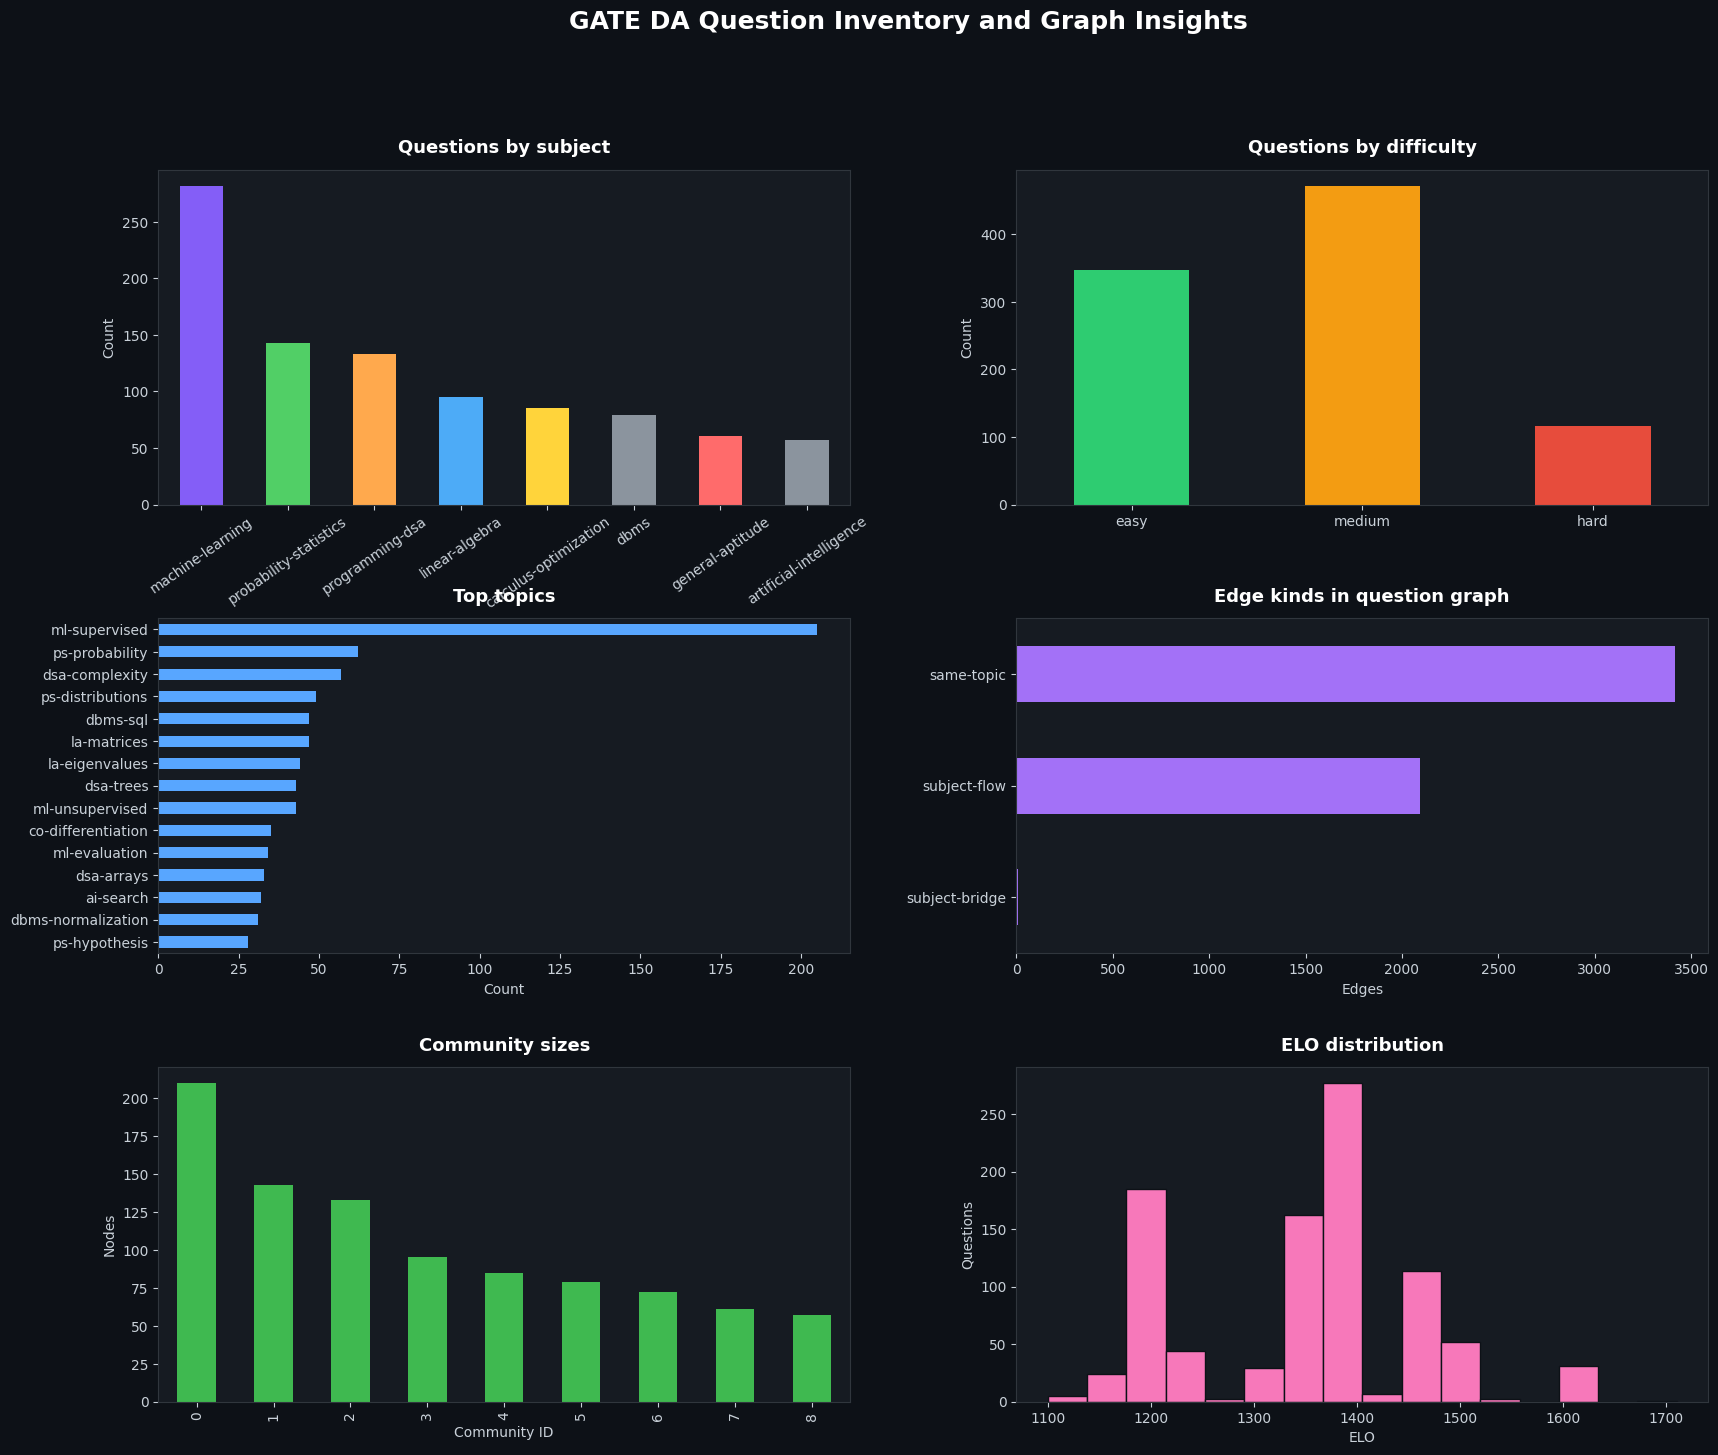

In [35]:
# ============================================================
# 8. INVENTORY + GRAPH INSIGHT PANELS
# ============================================================

subject_counts = questions_df["subjectId"].value_counts().sort_values(ascending=False)
difficulty_counts = questions_df["difficulty"].value_counts().reindex(["easy", "medium", "hard"]).fillna(0)
top_topics = questions_df["topicId"].value_counts().head(15)
community_sizes = Counter(questions_df["community_id"])
edge_kind_counts = Counter(data["edge_kind"] for _, _, data in question_graph.edges(data=True))

fig = plt.figure(figsize=(20, 16), facecolor="#0d1117")
fig.suptitle("GATE DA Question Inventory and Graph Insights", color="white", fontsize=18, fontweight="bold")
gs = GridSpec(3, 2, figure=fig, hspace=0.34, wspace=0.24)
panel = "#161b22"
text_c = "#c9d1d9"


def style_ax(ax, title):
    ax.set_facecolor(panel)
    ax.set_title(title, color="white", fontsize=13, pad=12, fontweight="bold")
    ax.tick_params(colors=text_c)
    for spine in ax.spines.values():
        spine.set_color("#30363d")


ax1 = fig.add_subplot(gs[0, 0])
style_ax(ax1, "Questions by subject")
subject_counts.plot(kind="bar", ax=ax1, color=[SUBJECT_COLORS.get(idx, "#8b949e") for idx in subject_counts.index])
ax1.set_ylabel("Count", color=text_c)
ax1.set_xlabel("")
ax1.tick_params(axis="x", rotation=35)

ax2 = fig.add_subplot(gs[0, 1])
style_ax(ax2, "Questions by difficulty")
difficulty_counts.plot(kind="bar", ax=ax2, color=[DIFF_COLOR.get(idx, "#8b949e") for idx in difficulty_counts.index])
ax2.set_ylabel("Count", color=text_c)
ax2.set_xlabel("")
ax2.tick_params(axis="x", rotation=0)

ax3 = fig.add_subplot(gs[1, 0])
style_ax(ax3, "Top topics")
top_topics.sort_values().plot(kind="barh", ax=ax3, color="#58a6ff")
ax3.set_xlabel("Count", color=text_c)
ax3.set_ylabel("")

ax4 = fig.add_subplot(gs[1, 1])
style_ax(ax4, "Edge kinds in question graph")
pd.Series(edge_kind_counts).sort_values().plot(kind="barh", ax=ax4, color="#a371f7")
ax4.set_xlabel("Edges", color=text_c)
ax4.set_ylabel("")

ax5 = fig.add_subplot(gs[2, 0])
style_ax(ax5, "Community sizes")
pd.Series(community_sizes).sort_values(ascending=False).head(15).plot(kind="bar", ax=ax5, color="#3fb950")
ax5.set_ylabel("Nodes", color=text_c)
ax5.set_xlabel("Community ID", color=text_c)

ax6 = fig.add_subplot(gs[2, 1])
style_ax(ax6, "ELO distribution")
ax6.hist(questions_df["eloRating"], bins=16, color="#f778ba", edgecolor="#0d1117")
ax6.set_xlabel("ELO", color=text_c)
ax6.set_ylabel("Questions", color=text_c)

plt.show()


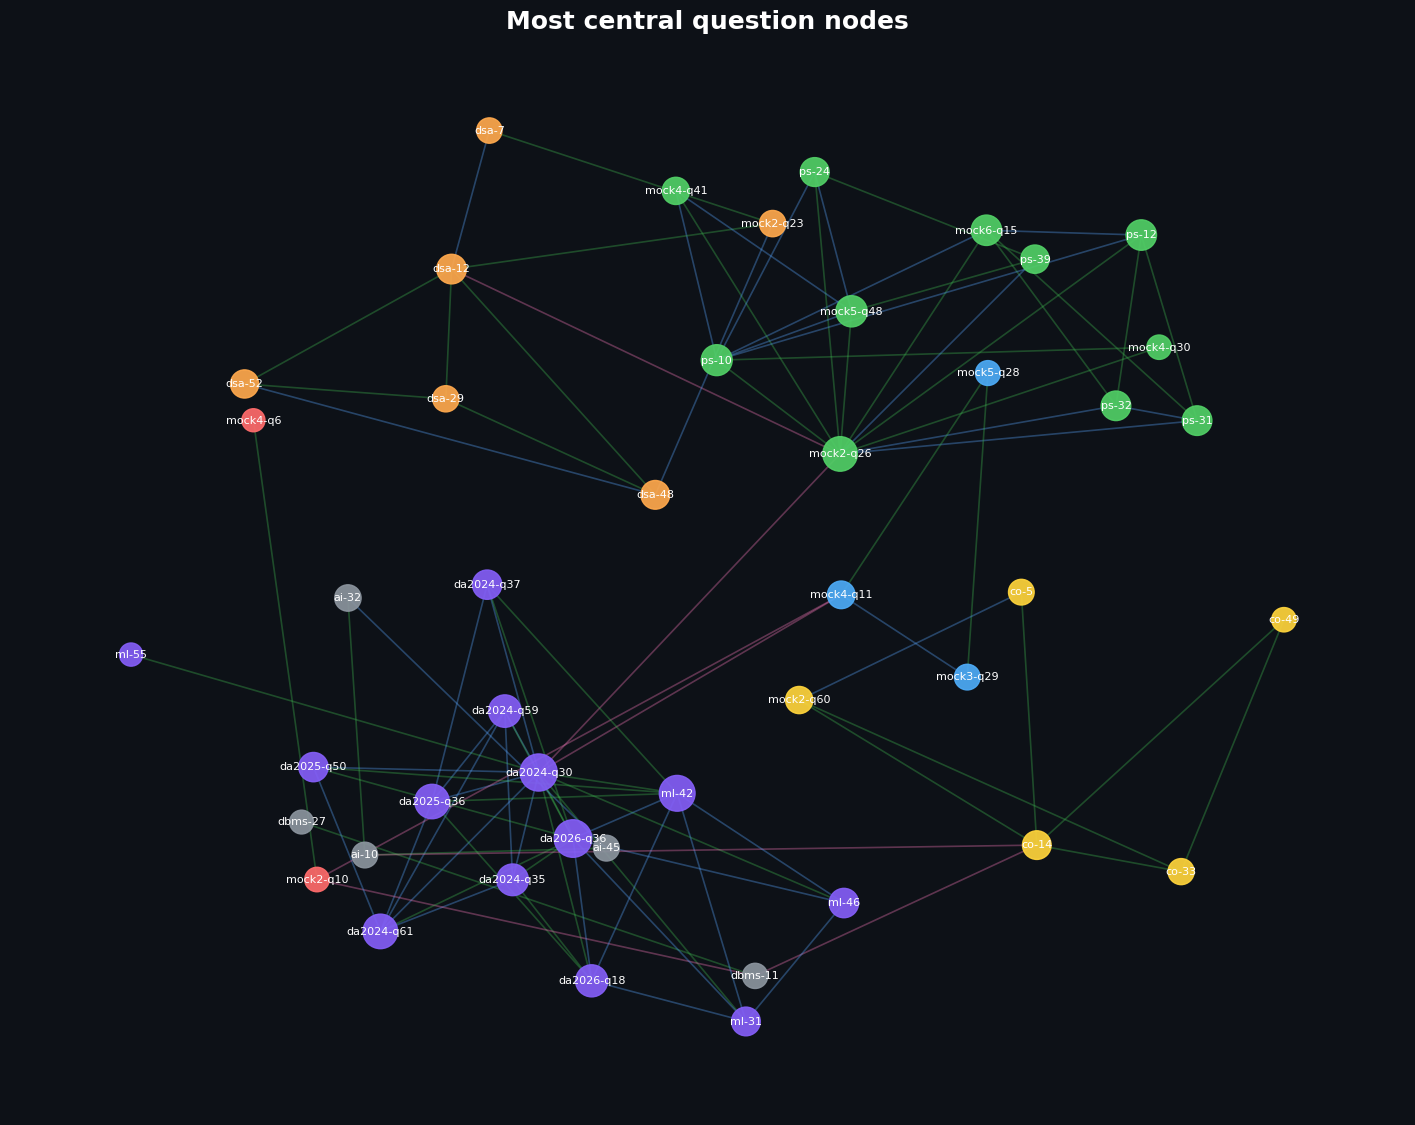

In [36]:
# ============================================================
# 9. VISUALIZE A SUBGRAPH OF THE MOST CENTRAL QUESTIONS
# ============================================================

top_nodes = questions_df.sort_values(["weighted_degree", "betweenness"], ascending=False)["node_id"].head(45).tolist()
subgraph = question_graph.subgraph(top_nodes).copy()

plt.figure(figsize=(18, 14), facecolor="#0d1117")
ax = plt.gca()
ax.set_facecolor("#0d1117")

pos = nx.spring_layout(subgraph, seed=42, k=0.7, weight="weight")
node_colors = [
    SUBJECT_COLORS.get(subgraph.nodes[node].get("subject", ""), "#8b949e")
    for node in subgraph.nodes()
]
node_sizes = [
    250 + subgraph.degree(node, weight="weight") * 75
    for node in subgraph.nodes()
]

edge_colors = []
for _, _, data in subgraph.edges(data=True):
    if data.get("edge_kind") == "same-topic":
        edge_colors.append("#58a6ff")
    elif data.get("edge_kind") == "subject-flow":
        edge_colors.append("#3fb950")
    else:
        edge_colors.append("#f778ba")

nx.draw_networkx_edges(subgraph, pos, alpha=0.35, edge_color=edge_colors, width=1.2)
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.92)
nx.draw_networkx_labels(
    subgraph,
    pos,
    labels={node: question_graph.nodes[node]["question_id"] for node in subgraph.nodes()},
    font_size=8,
    font_color="white",
)

plt.title("Most central question nodes", color="white", fontsize=18, fontweight="bold")
plt.axis("off")
plt.show()


In [37]:
# ============================================================
# 10. INSPECT A QUESTION NEIGHBORHOOD
# ============================================================

QUESTION_ID = globals().get("QUESTION_ID", questions_df.iloc[0]["id"])

match = questions_df.loc[questions_df["id"] == QUESTION_ID]
if match.empty:
    raise ValueError(f"Question ID not found: {QUESTION_ID}")

node_id = match.iloc[0]["node_id"]
center = question_graph.nodes[node_id]
neighbors = []
for neighbor in question_graph.neighbors(node_id):
    edge = question_graph.get_edge_data(node_id, neighbor)
    neighbor_row = questions_df.loc[questions_df["node_id"] == neighbor].iloc[0]
    neighbors.append(
        {
            "neighbor_question_id": neighbor_row["id"],
            "subjectId": neighbor_row["subjectId"],
            "topicId": neighbor_row["topicId"],
            "difficulty": neighbor_row["difficulty"],
            "eloRating": neighbor_row["eloRating"],
            "edge_kind": edge["edge_kind"],
            "weight": edge["weight"],
            "semantic": edge["semantic"],
        }
    )

neighbors_df = pd.DataFrame(neighbors).sort_values(["weight", "semantic"], ascending=False)

print("Center question:", center["question_id"])
print("Subject:", center["subject"])
print("Topic:", center["topic"])
print("Difficulty:", center["difficulty"])
display(neighbors_df.head(20))


Center question: da2025-q1
Subject: programming-dsa
Topic: dsa-arrays
Difficulty: easy


,neighbor_question_id,subjectId,topicId,difficulty,eloRating,edge_kind,weight,semantic
0,da2025-q2,programming-dsa,dsa-arrays,easy,1400.0,same-topic,0.9698,0.4857
1,da2025-q3,programming-dsa,dsa-arrays,easy,1400.0,same-topic,0.9566,0.4197
2,da2025-q4,programming-dsa,dsa-arrays,easy,1400.0,same-topic,0.9429,0.3514
3,da2025-q9,programming-dsa,dsa-arrays,medium,1400.0,same-topic,0.9331,0.3002
7,da2025-q5,programming-dsa,dsa-arrays,easy,1400.0,same-topic,0.9126,0.1996
4,dsa-42,programming-dsa,dsa-trees,medium,1400.0,subject-flow,0.5972,0.1207
5,dsa-60,programming-dsa,dsa-complexity,medium,1400.0,subject-flow,0.5971,0.1203
8,da2026-q25,programming-dsa,dsa-trees,easy,1400.0,subject-flow,0.5817,0.1094
6,dsa-12,programming-dsa,dsa-arrays,medium,1350.0,same-topic,0.5000,0.1716


In [38]:
# ============================================================
# 11. EXPORT THE GRAPH
# ============================================================

graphml_path = ROOT / "tmp_gate_da_question_graph.graphml"
json_path = ROOT / "tmp_gate_da_question_graph.json"

nx.write_graphml(question_graph, graphml_path)

export_payload = {
    "generatedAt": payload.get("generatedAt"),
    "nodeCount": question_graph.number_of_nodes(),
    "edgeCount": question_graph.number_of_edges(),
    "nodes": [
        {"id": node, **data}
        for node, data in question_graph.nodes(data=True)
    ],
    "edges": [
        {"source": source, "target": target, **data}
        for source, target, data in question_graph.edges(data=True)
    ],
}

json_path.write_text(json.dumps(export_payload, indent=2), encoding="utf-8")

print("Saved GraphML:", graphml_path)
print("Saved JSON:", json_path)


AttributeError: `np.float_` was removed in the NumPy 2.0 release. Use `np.float64` instead.